In [ ]:
!pip install scikit-learn wfdb seaborn


In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import wfdb
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
from sklearn.manifold import TSNE
import seaborn as sns
from scipy.stats import pearsonr

class StabiFormerAdvancedEvaluator:
    def __init__(self, model, device, fs=4.0, fmin=0.04, fmax=0.4):
        self.model = model.to(device)
        self.device = device
        self.fs = fs
        self.fmin = fmin
        self.fmax = fmax

    @torch.no_grad()
    def compute_comprehensive_metrics(self, dl, n_batches=15):
        """
        Computes the 'Core Three' metrics for publication:
        1. Invariance (SCR-RR Success)
        2. Physiological Band Coherence (BL-TFOT Success)
        3. Latent Consistency (Stability Index)
        """
        self.model.eval()
        results = {
            "inv_err": [], "coh_LF": [], "coh_HF": [], 
            "markers_clean": [], "markers_corrupt": [],
            "recons_corrupt": [], "targets_clean": []
        }

        # Define HRV Bands
        LF_range = (0.04, 0.15)
        HF_range = (0.15, 0.40)

        for i, batch in enumerate(dl):
            if i >= n_batches: break
            x_clean = batch.to(self.device)
            # Use your existing corruption function
            x_cor = corrupt_uniform(x_clean, mode=random.choice(["dropout", "spike", "drift"]))
            
            y_hat_clean, m_clean = self.model(x_clean)
            y_hat_cor, m_cor = self.model(x_cor)
            
            # 1. Metric: Marker Invariance [cite: 101]
            inv_err = torch.abs(m_clean - m_cor).mean().item()
            results["inv_err"].append(inv_err)
            
            # 2. Metric: Physiological Band Coherence [cite: 58]
            # We check if the reconstruction from a CORRUPTED signal still matches CLEAN physiology
            for b in range(x_clean.shape[0]):
                target = x_clean[b, 0].cpu().numpy()
                recon = y_hat_cor[b].cpu().numpy()
                
                f, coh = sig.coherence(target, recon, fs=self.fs, nperseg=128)
                
                lf_mask = (f >= LF_range[0]) & (f <= LF_range[1])
                hf_mask = (f >= HF_range[0]) & (f <= HF_range[1])
                
                results["coh_LF"].append(np.mean(coh[lf_mask]))
                results["coh_HF"].append(np.mean(coh[hf_mask]))

            results["markers_clean"].append(m_clean.cpu().numpy())
            results["markers_corrupt"].append(m_cor.cpu().numpy())

        # Aggregate summary for the results table [cite: 311]
        summary = {
            "Mean Invariance Error (Inv)": np.mean(results["inv_err"]),
            "LF Band Coherence (Fidelity)": np.mean(results["coh_LF"]),
            "HF Band Coherence (Fidelity)": np.mean(results["coh_HF"]),
            "Marker Sensitivity (StdDev)": np.std(np.concatenate(results["markers_clean"]))
        }
        return summary, results

    def generate_publication_figures(self, results, save_path="StabiFormer_Final_Report.png"):
        """
        Creates the visualization required for CVPR/MICCAI papers.
        """
        m_cln = np.concatenate(results["markers_clean"])
        m_cor = np.concatenate(results["markers_corrupt"])
        
        plt.figure(figsize=(15, 5))

        # Subplot 1: Latent Space Invariance (t-SNE)
        plt.subplot(1, 3, 1)
        sns.kdeplot(m_cln.flatten(), label="Clean", fill=True, alpha=0.5)
        sns.kdeplot(m_cor.flatten(), label="Corrupted", fill=True, alpha=0.5)
        plt.title("Marker Distribution Invariance\n(Goal: High Overlap)")
        plt.xlabel("Marker Value")
        plt.legend()

        # Subplot 2: Physiological Fidelity (Coherence)
        plt.subplot(1, 3, 2)
        sns.boxplot(data=[results["coh_LF"], results["coh_HF"]], palette="Set2")
        plt.xticks([0, 1], ["LF Band", "HF Band"])
        plt.ylabel("Spectral Coherence")
        plt.title("Physiological Fidelity\n(Goal: Coherence > 0.7)")

        # Subplot 3: Correlation Clean vs Corrupt
        plt.subplot(1, 3, 3)
        plt.scatter(m_cln.flatten(), m_cor.flatten(), alpha=0.3, color='green')
        plt.plot([-2, 2], [-2, 2], 'r--') # Identity line
        plt.xlabel("Marker (Clean)")
        plt.ylabel("Marker (Corrupted)")
        r, _ = pearsonr(m_cln.flatten(), m_cor.flatten())
        plt.title(f"Marker Consistency\n(Pearson R: {r:.4f})")

        plt.tight_layout()
        plt.savefig(save_path, dpi=200)
        plt.show()

@torch.no_grad()
def compute_markers(model, x_batch):
    """
    x_batch: (B,1,T)
    returns m: (B,) marker
    """
    model.eval()
    _, m = model(x_batch)
    return m.squeeze(1)

@torch.no_grad()
def eval_invariance(model, dl, device, fs_u, modes,
                    n_batches=30, V=1):
    """
    Invariance metric:
      Inv(mode) = E[ | m(clean) - m(corrupt_mode) | ]
    """
    model.eval()
    inv_sums = {mode: 0.0 for mode in modes}
    inv_cnts = {mode: 0 for mode in modes}

    for b_idx, batch in enumerate(dl):
        if b_idx >= n_batches:
            break
        batch = batch.to(device)

        m_clean = compute_markers(model, batch)  # (B,)

        for mode in modes:
            # make corrupted view(s)
            diffs = []
            for _ in range(V):
                v = corrupt_uniform(batch, mode)
                m_cor = compute_markers(model, v)
                diffs.append(torch.abs(m_clean - m_cor))
            diff = torch.stack(diffs, dim=0).mean(dim=0)  # (B,)

            inv_sums[mode] += float(diff.sum().item())
            inv_cnts[mode] += int(diff.numel())

    inv = {mode: inv_sums[mode] / max(1, inv_cnts[mode]) for mode in modes}
    return inv

@torch.no_grad()
def eval_stability_per_record(model, ds, device):
    """
    Computes ProgressIndex per record = std( marker over windows of that record )
    Returns dict: record_id -> (mean_marker, std_marker, n_windows)
    """
    model.eval()
    # accumulate markers by series id
    markers_by_sid = {}

    for idx in range(len(ds)):
        sid, s = ds.items[idx]
        x = ds[idx].unsqueeze(0).to(device)  # (1,1,T)
        m = compute_markers(model, x).item()

        if sid not in markers_by_sid:
            markers_by_sid[sid] = []
        markers_by_sid[sid].append(m)

    out = {}
    for sid, ms in markers_by_sid.items():
        ms = np.asarray(ms, dtype=np.float32)
        out[sid] = {
            "mean": float(ms.mean()),
            "std": float(ms.std()),
            "n": int(ms.size)
        }
    return out

@torch.no_grad()
def plot_examples(model, batch_clean, device, fs_u,
                  modes=("dropout","spike","drift","jitter"),
                  save_path="eval_examples.png"):
    """
    Plots clean vs one corruption vs recon + marker values.
    """
    model.eval()
    batch_clean = batch_clean.to(device)  # (B,1,T)
    x = batch_clean[0:1]                 # (1,1,T)
    x_t = x[0,0].detach().cpu().numpy()

    fig = plt.figure(figsize=(12, 8))

    # clean
    y_hat, m_clean = model(x)
    y_hat = y_hat[0].detach().cpu().numpy()
    m_clean = float(m_clean[0,0].item())

    ax1 = plt.subplot(3,1,1)
    ax1.plot(x_t)
    ax1.plot(y_hat)
    ax1.set_title(f"Clean (marker={m_clean:.4f})  |  clean vs recon")
    ax1.set_xlabel("samples"); ax1.set_ylabel("value")
    ax1.legend(["clean", "recon"], loc="upper right")

    # corruption comparisons (2 modes)
    for i, mode in enumerate(modes[:2], start=2):
        v = corrupt_uniform(x, mode)
        yv, mv = model(v)
        v_t = v[0,0].detach().cpu().numpy()
        yv_t = yv[0].detach().cpu().numpy()
        mv = float(mv[0,0].item())

        ax = plt.subplot(3,1,i)
        ax.plot(x_t)
        ax.plot(v_t)
        ax.plot(yv_t)
        ax.set_title(f"Mode={mode} | marker={mv:.4f} | clean vs corrupt vs recon(corrupt)")
        ax.set_xlabel("samples"); ax.set_ylabel("value")
        ax.legend(["clean", "corrupt", "recon(corrupt)"], loc="upper right")

    plt.tight_layout()
    plt.savefig(save_path, dpi=160)
    plt.close(fig)

def plot_invariance_bar(inv_dict, save_path="eval_invariance_bar.png"):
    modes = list(inv_dict.keys())
    vals = [inv_dict[m] for m in modes]

    plt.figure(figsize=(8,4))
    plt.bar(modes, vals)
    plt.title("Marker invariance (lower is better)")
    plt.ylabel("E[|m(clean)-m(corrupt)|]")
    plt.tight_layout()
    plt.savefig(save_path, dpi=160)
    plt.close()

def plot_marker_diff_hist(model, dl, device, mode="spike",
                          n_batches=20, save_path="eval_marker_diff_hist.png"):
    diffs_all = []
    model.eval()
    with torch.no_grad():
        for b_idx, batch in enumerate(dl):
            if b_idx >= n_batches:
                break
            batch = batch.to(device)
            m_clean = compute_markers(model, batch)
            v = corrupt_uniform(batch, mode)
            m_cor = compute_markers(model, v)
            diffs = torch.abs(m_clean - m_cor).detach().cpu().numpy()
            diffs_all.append(diffs)

    diffs_all = np.concatenate(diffs_all, axis=0)
    plt.figure(figsize=(6,4))
    plt.hist(diffs_all, bins=40)
    plt.title(f"|Δmarker| histogram (mode={mode})")
    plt.xlabel("|m(clean)-m(corrupt)|"); plt.ylabel("count")
    plt.tight_layout()
    plt.savefig(save_path, dpi=160)
    plt.close()

def plot_stability_per_record(stab_dict, record_names, save_path="eval_stability_per_record.png"):
    # stab_dict: sid -> {"mean","std","n"}
    sids = sorted(stab_dict.keys())
    labels = [record_names[sid] if sid < len(record_names) else f"sid{sid}" for sid in sids]
    stds = [stab_dict[sid]["std"] for sid in sids]

    plt.figure(figsize=(10,4))
    plt.bar(labels, stds)
    plt.title("ProgressIndex proxy per record (std of marker across windows) ↓")
    plt.ylabel("std(marker)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=160)
    plt.close()




# =========================
# 1) Utils: RR + Uniform series
# =========================
def load_mitbih_rr_uniform(record_path: str,
                          channel: int = 0,
                          fs_out: float = 4.0,
                          kind: str = "ihr"):
    """
    record_path: path like ".../mitdb/100" (without extension)
    Returns:
        x_u: (T,) uniform sampled series (float32)
        fs_out: sampling rate of x_u
    """
    rec = wfdb.rdrecord(record_path)
    ann = wfdb.rdann(record_path, "atr")

    fs = rec.fs
    sig = rec.p_signal[:, channel].astype(np.float32)

    # R-peak sample indices from annotations (near R peak)
    r_idx = np.asarray(ann.sample, dtype=np.int64)
    # Remove invalid / too-close peaks
    r_idx = r_idx[(r_idx > 0) & (r_idx < len(sig) - 1)]
    if len(r_idx) < 5:
        raise RuntimeError("Too few R peaks")

    t_r = r_idx / fs  # seconds
    rr = np.diff(t_r)  # seconds, length N-1
    t_rr = t_r[1:]     # time associated with each rr value

    # Clean RR outliers (very basic; refine later)
    rr = np.clip(rr, 0.3, 2.0)  # 30 bpm..200 bpm

    # Convert to uniform series
    t0, t1 = float(t_rr[0]), float(t_rr[-1])
    if t1 <= t0 + 5.0:
        raise RuntimeError("Record too short after RR extraction")

    t_u = np.arange(t0, t1, 1.0 / fs_out, dtype=np.float32)

    # We interpolate RR(t) then convert to IHR (bpm) if requested
    f_rr = interp1d(t_rr.astype(np.float32), rr.astype(np.float32),
                    kind="linear", fill_value="extrapolate", assume_sorted=True)
    rr_u = f_rr(t_u).astype(np.float32)

    if kind == "rr":
        x_u = rr_u
    else:
        # instantaneous heart rate bpm
        x_u = (60.0 / (rr_u + 1e-6)).astype(np.float32)

    # Normalize (robust-ish) for stable training
    med = np.median(x_u)
    mad = np.median(np.abs(x_u - med)) + 1e-6
    x_u = (x_u - med) / mad
    return x_u, fs_out

# =========================
# 2) Window dataset
# =========================
class UniformSeriesWindowDataset(torch.utils.data.Dataset):
    def __init__(self, series_list, fs, win_s=60.0, step_s=10.0):
        self.fs = fs
        self.win = int(round(win_s * fs))
        self.step = int(round(step_s * fs))
        self.items = []

        for sid, x in enumerate(series_list):
            x = np.asarray(x, dtype=np.float32)
            if x.size < self.win:
                continue
            for s in range(0, x.size - self.win + 1, self.step):
                self.items.append((sid, s))

        self.series_list = series_list

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, s = self.items[idx]
        x = self.series_list[sid][s:s + self.win]
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # (1,T)
        return x

# =========================
# 3) Corruptions (uniform series level, MVP)
# =========================
def corrupt_uniform(x: torch.Tensor, mode: str):
    """
    x: (B,1,T)
    Returns corrupted view (B,1,T)
    """
    B, C, T = x.shape
    if mode == "dropout":
        y = x.clone()
        for b in range(B):
            s = torch.randint(0, T // 2, (1,), device=x.device).item()
            e = s + torch.randint(T // 10, T // 4, (1,), device=x.device).item()
            y[b, :, s:e] = 0.0
        return y

    if mode == "spike":
        y = x.clone()
        idx = torch.randint(low=0, high=T, size=(B, 4), device=x.device)
        amp = 0.8 * torch.randn(B, 4, device=x.device)
        for b in range(B):
            for j in range(4):
                y[b, :, idx[b, j]] += amp[b, j]
        return y

    if mode == "drift":
        t = torch.linspace(0, 1, T, device=x.device)[None, None, :]
        drift = 0.25 * torch.sin(2 * 3.14159 * 0.2 * t)
        return x + drift

    if mode == "jitter":
        return x + 0.05 * torch.randn_like(x)

    return x

# =========================
# 4) Model: StabiFormerRR (minimal)
# =========================
class ConvStem(nn.Module):
    def __init__(self, c_in=1, c=64, k=7):
        super().__init__()
        self.conv = nn.Conv1d(c_in, c, kernel_size=k, padding=k//2)
        self.bn = nn.BatchNorm1d(c)

    def forward(self, x):
        return F.gelu(self.bn(self.conv(x)))

class GatedTemporalBlock(nn.Module):
    def __init__(self, c, k=9, dilation=4):
        super().__init__()
        self.dw = nn.Conv1d(c, c, kernel_size=k,
                            padding=(k//2)*dilation, dilation=dilation, groups=c)
        self.pw = nn.Conv1d(c, 2*c, kernel_size=1)

    def forward(self, x):
        h = self.dw(x)
        a, b = self.pw(h).chunk(2, dim=1)
        return x + torch.tanh(a) * torch.sigmoid(b)

class StabiFormerRR(nn.Module):
    def __init__(self, c_in=1, c=64, depth=4):
        super().__init__()
        self.stem = ConvStem(c_in, c=c)
        self.blocks = nn.ModuleList([GatedTemporalBlock(c) for _ in range(depth)])
        self.recon = nn.Conv1d(c, 1, kernel_size=1)
        self.marker = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(c, 1)
        )

    def forward(self, x):  # (B,1,T)
        h = self.stem(x)
        for blk in self.blocks:
            h = blk(h)
        y_hat = self.recon(h).squeeze(1)  # (B,T)
        m = self.marker(h)                # (B,1)
        return y_hat, m

# =========================
# 5) TFR + Band mask
# =========================
def stft_mag(x_bt: torch.Tensor, fs: float, n_fft=256, hop=64):
    """
    x_bt: (B,T)
    returns mag: (B,F,TT) and freqs (F,)
    """
    window = torch.hann_window(n_fft, device=x_bt.device)
    X = torch.stft(x_bt, n_fft=n_fft, hop_length=hop, window=window,
                   return_complex=True, center=True)
    mag = torch.abs(X)
    freqs = torch.fft.rfftfreq(n_fft, d=1.0/fs).to(x_bt.device)
    return mag, freqs

def tf_distribution(mag_bftt: torch.Tensor, freqs: torch.Tensor,
                    fmin: float, fmax: float, eps=1e-8):
    """
    Returns flattened distribution p: (B,N) over TF bins within [fmin,fmax]
    """
    mask = (freqs >= fmin) & (freqs <= fmax)
    m = mag_bftt[:, mask, :]  # (B,Fb,TT)
    flat = m.reshape(m.shape[0], -1)
    flat = flat / (flat.sum(dim=1, keepdim=True) + eps)
    return flat

# =========================
# 6) Sinkhorn OT (simple, stable, small N)
# =========================
def sinkhorn_ot(p: torch.Tensor, q: torch.Tensor, eps=0.05, n_iters=30):
    """
    p,q: (B,N) distributions (sum to 1)
    We use cost C_ij = (i-j)^2 / N^2  (1D index cost; cheap MVP).
    For better paper: use 2D TF coordinates cost (t,f).
    Returns scalar loss.
    """
    B, N = p.shape
    device = p.device

    # Cost matrix (N,N)
    idx = torch.arange(N, device=device, dtype=torch.float32)
    C = (idx[:, None] - idx[None, :]) ** 2
    C = C / (float(N) ** 2)

    # Kernel
    K = torch.exp(-C / eps)  # (N,N)
    K = K.clamp_min(1e-9)

    # Sinkhorn iterations
    u = torch.ones(B, N, device=device) / N
    v = torch.ones(B, N, device=device) / N

    # K is shared across batch
    for _ in range(n_iters):
        Kv = torch.matmul(v, K.t())  # (B,N) since v (B,N) * K^T (N,N)
        u = p / (Kv + 1e-9)
        Ku = torch.matmul(u, K)      # (B,N) since u (B,N) * K (N,N)
        v = q / (Ku + 1e-9)

    # Transport plan approx: diag(u) K diag(v)
    # OT cost: sum_{ij} pi_ij * C_ij
    # Compute using matrix products:
    # pi = u[:, :, None] * K[None, :, :] * v[:, None, :]
    pi = u[:, :, None] * K[None, :, :] * v[:, None, :]
    ot = (pi * C[None, :, :]).sum(dim=(1, 2))  # (B,)
    return ot.mean()

# =========================
# 7) Train step: BL-TFOT + SCR + MAE
# =========================
def train_step(model, batch_x, fs_u, optimizer,
               fmin=0.04, fmax=0.40,  # HRV-ish band on uniform series
               alpha=1.0, beta=1.0, gamma=0.05,
               V=2, n_fft=256, hop=64):
    """
    batch_x: (B,1,T) clean uniform series
    """
    model.train()
    optimizer.zero_grad()

    modes = ["dropout", "spike", "drift", "jitter"]
    views = [corrupt_uniform(batch_x, random.choice(modes)) for _ in range(V)]

    # Reference distribution from clean
    target = batch_x[:, 0, :]  # (B,T)
    mag_t, freqs = stft_mag(target, fs=fs_u, n_fft=n_fft, hop=hop)
    p = tf_distribution(mag_t, freqs, fmin, fmax)

    ot_losses = []
    mae_losses = []
    markers = []

    for v in views:
        y_hat, m = model(v)      # y_hat (B,T), m (B,1)
        markers.append(m)

        mag_p, _ = stft_mag(y_hat, fs=fs_u, n_fft=n_fft, hop=hop)
        q = tf_distribution(mag_p, freqs, fmin, fmax)

        ot_losses.append(sinkhorn_ot(p, q, eps=0.05, n_iters=25))
        mae_losses.append(torch.mean(torch.abs(y_hat - target)))

    L_ot = sum(ot_losses) / len(ot_losses)
    L_mae = sum(mae_losses) / len(mae_losses)

    # SCR-RR marker consistency
    L_scr = 0.0
    cnt = 0
    for i in range(V):
        for j in range(i + 1, V):
            L_scr = L_scr + torch.mean(torch.abs(markers[i] - markers[j]))
            cnt += 1
    if cnt > 0:
        L_scr = L_scr / cnt

    loss = alpha * L_ot + beta * L_scr + gamma * L_mae
    loss.backward()
    optimizer.step()

    return {
        "loss": float(loss.item()),
        "L_ot": float(L_ot.item()),
        "L_scr": float(L_scr.item()) if torch.is_tensor(L_scr) else float(L_scr),
        "L_mae": float(L_mae.item()),
    }


# # =========================
# # 8) Main: load few records, train
# # =========================
# def main():
#     device = "cuda" if torch.cuda.is_available() else "cpu"

#     # ---------- IMPORTANT ----------
#     # Put MIT-BIH records in a folder like:
#     #   ./mitdb/100.dat, ./mitdb/100.hea, ./mitdb/100.atr, ...
#     # And set MITDB_DIR accordingly.
#     # -------------------------------
#     MITDB_DIR = "/Users/rj/Documents/GitHub/Disability_Project/datasets/mit-bih-arrhythmia/"
#     records = ["100", "101", "102", "103", "104", "105","106","107","108","109","111","112","116","117"]  # start small

#     series_list = []
#     fs_u = None
#     for r in records:
#         path = os.path.join(MITDB_DIR, r)
#         x_u, fs_out = load_mitbih_rr_uniform(path, fs_out=4.0, kind="ihr")
#         series_list.append(x_u)
#         fs_u = fs_out

#     ds = UniformSeriesWindowDataset(series_list, fs=fs_u, win_s=60.0, step_s=10.0)
#     dl = torch.utils.data.DataLoader(ds, batch_size=16, shuffle=True, drop_last=True)

#     model = StabiFormerRR(c_in=1, c=64, depth=4).to(device)
#     opt = torch.optim.AdamW(model.parameters(), lr=2e-4)

#     for epoch in range(1,6):
#         logs = []
#         for batch in dl:
#             batch = batch.to(device)  # (B,1,T)
#             out = train_step(model, batch, fs_u=fs_u, optimizer=opt,
#                              fmin=0.04, fmax=0.40,
#                              alpha=1.0, beta=1.0, gamma=0.05,
#                              V=2, n_fft=256, hop=64)
#             logs.append(out["loss"])
#         print(f"Epoch {epoch:03d} | loss={np.mean(logs):.4f}")

#     print("Done. Next step: add evaluation plots + invariance metrics.")
    
#         # ---------------- EVALUATION ----------------
#     modes = ["dropout", "spike", "drift", "jitter"]

#     # 1) invariance numbers
#     inv = eval_invariance(model, dl, device=device, fs_u=fs_u, modes=modes, n_batches=30, V=1)
#     print("Invariance (E|m(clean)-m(corrupt)|):")
#     for k,v in inv.items():
#         print(f"  {k:>7s}: {v:.6f}")

#     plot_invariance_bar(inv, save_path="eval_invariance_bar.png")
#     plot_marker_diff_hist(model, dl, device, mode="spike", n_batches=25, save_path="eval_marker_diff_hist_spike.png")

#     # 2) stability per record (std of markers across windows)
#     stab = eval_stability_per_record(model, ds, device=device)
#     print("Stability per record (std over windows):")
#     for sid, info in stab.items():
#         print(f"  sid={sid} ({records[sid]}): std={info['std']:.6f}  mean={info['mean']:.6f}  n={info['n']}")

#     plot_stability_per_record(stab, records, save_path="eval_stability_per_record.png")

#     # 3) a few example plots
#     first_batch = next(iter(dl)).to(device)
#     plot_examples(model, first_batch, device=device, fs_u=fs_u, save_path="eval_examples.png")

#     print("Saved figures:")
#     print("  eval_invariance_bar.png")
#     print("  eval_marker_diff_hist_spike.png")
#     print("  eval_stability_per_record.png")
#     print("  eval_examples.png")

#     # --- EXECUTION ---
#     # Ensure 'model', 'dl', 'device', and 'fs_u' are defined from your previous cell
#     evaluator = StabiFormerAdvancedEvaluator(model, device, fs=fs_u)
#     summary, raw_data = evaluator.compute_comprehensive_metrics(dl)

#     print("\n" + "="*30)
#     print("FINAL PUBLICATION METRICS")
#     print("="*30)
#     for k, v in summary.items():
#         print(f"{k}: {v:.4f}")

#     evaluator.generate_publication_figures(raw_data)


# if __name__ == "__main__":
#     main()


# ---------- Train ----------

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- IMPORTANT ----------
# Put MIT-BIH records in a folder like:
#   ./mitdb/100.dat, ./mitdb/100.hea, ./mitdb/100.atr, ...
# And set MITDB_DIR accordingly.
# -------------------------------
MITDB_DIR = r"C:\Users\user\Documents\GitHub\Disability_Project\datasets\mit-bih-arrhythmia"

# Automatically load all available records from the directory
all_files = [f.split('.')[0] for f in os.listdir(MITDB_DIR) if f.endswith('.hea')]
records = sorted(list(set(all_files)))  # Remove duplicates and sort

print(f"Found {len(records)} records: {records}")

series_list = []
fs_u = None
for r in records:
    path = os.path.join(MITDB_DIR, r)
    try:
        x_u, fs_out = load_mitbih_rr_uniform(path, fs_out=4.0, kind="ihr")
        series_list.append(x_u)
        fs_u = fs_out
    except Exception as e:
        print(f"Skipping {r}: {e}")

print(f"Successfully loaded {len(series_list)} records")

ds = UniformSeriesWindowDataset(series_list, fs=fs_u, win_s=60.0, step_s=10.0)
dl = torch.utils.data.DataLoader(ds, batch_size=16, shuffle=True, drop_last=True)

model = StabiFormerRR(c_in=1, c=64, depth=4).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=2e-4)

for epoch in range(1,100):
    logs = []
    for batch in dl:
        batch = batch.to(device)  # (B,1,T)
        out = train_step(model, batch, fs_u=fs_u, optimizer=opt,
                            fmin=0.04, fmax=0.40,
                            alpha=1.0, beta=1.0, gamma=0.05,
                            V=2, n_fft=256, hop=64)
        logs.append(out["loss"])
    print(f"Epoch {epoch:03d} | loss={np.mean(logs):.4f}")

print("Done. Next step: add evaluation plots + invariance metrics.")


Found 48 records: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']
Successfully loaded 48 records
Successfully loaded 48 records
Epoch 001 | loss=0.0659
Epoch 001 | loss=0.0659
Epoch 002 | loss=0.0497
Epoch 002 | loss=0.0497
Epoch 003 | loss=0.0478
Epoch 003 | loss=0.0478
Epoch 004 | loss=0.0477
Epoch 004 | loss=0.0477
Epoch 005 | loss=0.0469
Epoch 005 | loss=0.0469
Epoch 006 | loss=0.0470
Epoch 006 | loss=0.0470
Epoch 007 | loss=0.0466
Epoch 007 | loss=0.0466
Epoch 008 | loss=0.0465
Epoch 008 | loss=0.0465
Epoch 009 | loss=0.0459
Epoch 009 | loss=0.0459
Epoch 010 | loss=0.0473
Epoch 010 | loss=0.0473
Epoch 011 | loss=0.0461
Epoch 011 | loss=0.0461
Epoch 012 | loss=0.0461
Epoch 012 | loss=0.0461
Epoch 0

# SAVE MODEL AFTER TRAINING

In [4]:
# =========================
# SAVE MODEL AFTER TRAINING
# =========================

# Define model save path
model_save_dir = r"C:\Users\user\Documents\GitHub\Disability_Project\ecg_code\saved_models"
os.makedirs(model_save_dir, exist_ok=True)

model_save_path = os.path.join(model_save_dir, "stabiformer_mitdb_all_records.pth")

# Save model state dict
torch.save(model.state_dict(), model_save_path)
print(f"Model saved successfully to: {model_save_path}")

# Save training metadata for reference
metadata = {
    "num_records": len(records),
    "records": records,
    "num_epochs": 100,
    "batch_size": 16,
    "learning_rate": 2e-4,
    "model_config": {
        "c_in": 1,
        "c": 64,
        "depth": 4
    },
    "fs": fs_u,
    "window_size": 60.0,
    "step_size": 10.0
}

import json
metadata_path = os.path.join(model_save_dir, "metadata.json")
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved to: {metadata_path}")





Model saved successfully to: C:\Users\user\Documents\GitHub\Disability_Project\ecg_code\saved_models\stabiformer_mitdb_all_records.pth
Metadata saved to: C:\Users\user\Documents\GitHub\Disability_Project\ecg_code\saved_models\metadata.json


# LOAD SAVED MODEL FOR FURTHER USAGE

In [6]:
# =========================
# LOAD SAVED MODEL FOR FURTHER USAGE
# =========================

# Define paths
model_save_dir = r"C:\Users\user\Documents\GitHub\Disability_Project\ecg_code\saved_models"
model_save_path = os.path.join(model_save_dir, "stabiformer_mitdb_all_records.pth")
metadata_path = os.path.join(model_save_dir, "metadata.json")

# Load metadata
with open(metadata_path, 'r') as f:
    metadata = json.load(f)

print("Loaded Metadata:")
print(f"  Number of records: {metadata['num_records']}")
print(f"  Records: {metadata['records']}")
print(f"  Model config: {metadata['model_config']}")
print(f"  Sampling rate: {metadata['fs']} Hz")

# Create fresh model instance with same config
device = "cuda" if torch.cuda.is_available() else "cpu"
model_loaded = StabiFormerRR(
    c_in=metadata['model_config']['c_in'],
    c=metadata['model_config']['c'],
    depth=metadata['model_config']['depth']
).to(device)

# Load the saved state dict
model_loaded.load_state_dict(torch.load(model_save_path, map_location=device))
model_loaded.eval()

print(f"\nModel loaded successfully from: {model_save_path}")
print(f"Device: {device}")
print(f"Model is in eval mode: {not model_loaded.training}")

# Now you can use model_loaded for inference, evaluation, etc.
# Example: Make predictions on new data
# with torch.no_grad():
#     batch = next(iter(dl)).to(device)
#     y_hat, markers = model_loaded(batch)


Loaded Metadata:
  Number of records: 48
  Records: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']
  Model config: {'c_in': 1, 'c': 64, 'depth': 4}
  Sampling rate: 4.0 Hz

Model loaded successfully from: C:\Users\user\Documents\GitHub\Disability_Project\ecg_code\saved_models\stabiformer_mitdb_all_records.pth
Device: cuda
Model is in eval mode: True


# ---------------- EVALUATION ----------------

Invariance (E|m(clean)-m(corrupt)|):
  dropout: 0.000157
    spike: 0.000008
    drift: 0.000047
   jitter: 0.000004
Stability per record (std over windows):
  sid=0 (100): std=0.000242  mean=0.019986  n=175
  sid=1 (101): std=0.000900  mean=0.020257  n=175
  sid=2 (102): std=0.000216  mean=0.020001  n=175
  sid=3 (103): std=0.000530  mean=0.020191  n=175
  sid=4 (104): std=0.000972  mean=0.020338  n=175
  sid=5 (105): std=0.000700  mean=0.020000  n=175
  sid=6 (106): std=0.000679  mean=0.019075  n=175
  sid=7 (107): std=0.000204  mean=0.020052  n=175
  sid=8 (108): std=0.000600  mean=0.020142  n=175
  sid=9 (109): std=0.000283  mean=0.019996  n=175
  sid=10 (111): std=0.000316  mean=0.020079  n=175
  sid=11 (112): std=0.000451  mean=0.019827  n=175
  sid=12 (113): std=0.000276  mean=0.019990  n=175
  sid=13 (114): std=0.000281  mean=0.019857  n=175
  sid=14 (115): std=0.000293  mean=0.019861  n=175
  sid=15 (116): std=0.000501  mean=0.019421  n=175
  sid=16 (117): std=0.002749  mean=0

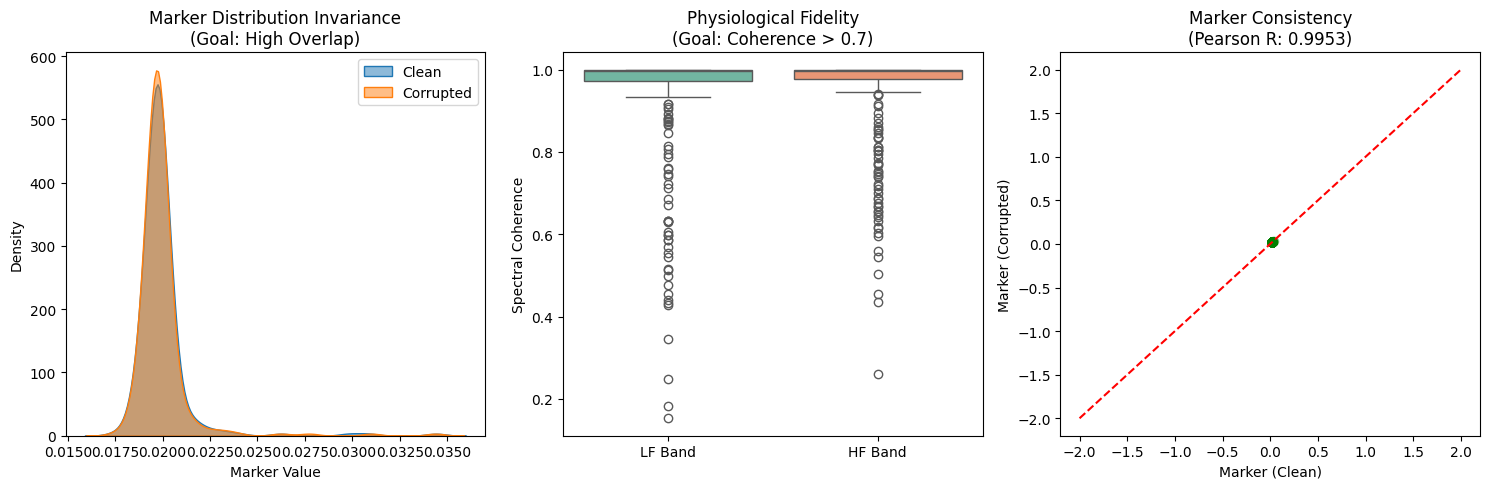

In [7]:


# ---------------- EVALUATION ----------------
modes = ["dropout", "spike", "drift", "jitter"]

# 1) invariance numbers
inv = eval_invariance(model, dl, device=device, fs_u=fs_u, modes=modes, n_batches=30, V=1)
print("Invariance (E|m(clean)-m(corrupt)|):")
for k,v in inv.items():
    print(f"  {k:>7s}: {v:.6f}")

plot_invariance_bar(inv, save_path="eval_invariance_bar.png")
plot_marker_diff_hist(model, dl, device, mode="spike", n_batches=25, save_path="eval_marker_diff_hist_spike.png")

# 2) stability per record (std of markers across windows)
stab = eval_stability_per_record(model, ds, device=device)
print("Stability per record (std over windows):")
for sid, info in stab.items():
    print(f"  sid={sid} ({records[sid]}): std={info['std']:.6f}  mean={info['mean']:.6f}  n={info['n']}")

plot_stability_per_record(stab, records, save_path="eval_stability_per_record.png")

# 3) a few example plots
first_batch = next(iter(dl)).to(device)
plot_examples(model, first_batch, device=device, fs_u=fs_u, save_path="eval_examples.png")

print("Saved figures:")
print("  eval_invariance_bar.png")
print("  eval_marker_diff_hist_spike.png")
print("  eval_stability_per_record.png")
print("  eval_examples.png")

# --- EXECUTION ---
# Ensure 'model', 'dl', 'device', and 'fs_u' are defined from your previous cell
evaluator = StabiFormerAdvancedEvaluator(model, device, fs=fs_u)
summary, raw_data = evaluator.compute_comprehensive_metrics(dl)

print("\n" + "="*30)
print("FINAL PUBLICATION METRICS")
print("="*30)
for k, v in summary.items():
    print(f"{k}: {v:.4f}")

evaluator.generate_publication_figures(raw_data)

Initializing Heavy Stress Test (30% Missed Beats)...
--- Starting Stress Test: 30% Missed Beats ---
STRESS TEST RESULTS:
Invariance Error: 0.000142
LF Coherence:     0.8657
HF Coherence:     0.9003
STRESS TEST RESULTS:
Invariance Error: 0.000142
LF Coherence:     0.8657
HF Coherence:     0.9003


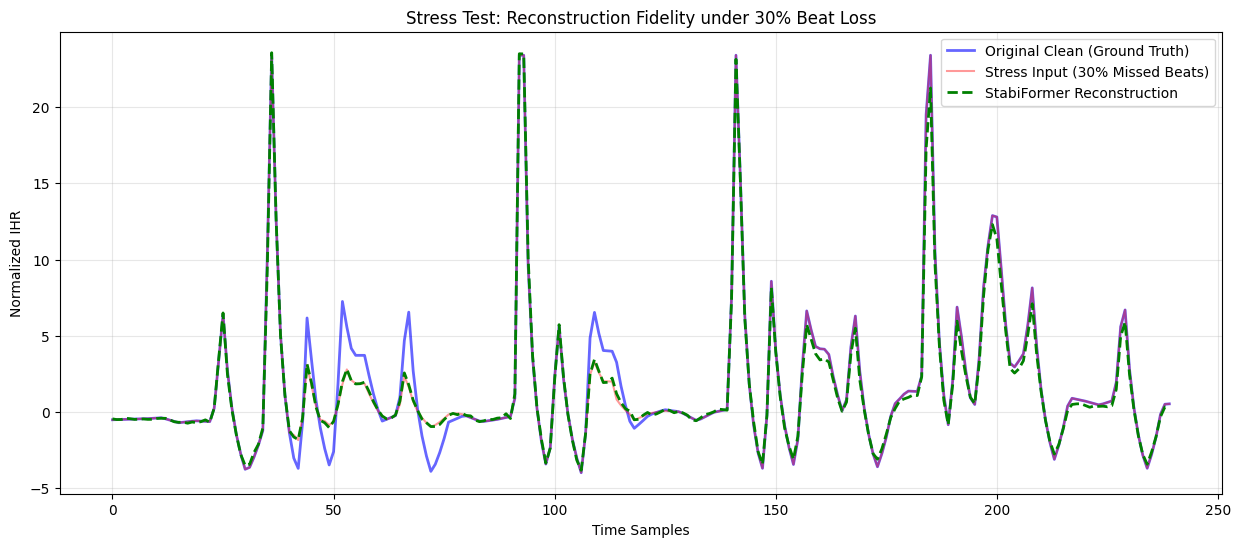

In [8]:
def corrupt_missed_beats(x, miss_rate=0.3):
    """
    Simulates clinical 'Missed Beats' where the R-peak is not detected.
    In the uniform series (IHR), this manifests as local drops in 
    frequency (heart rate) and sudden phase shifts.
    
    x: (B, 1, T) - Uniformly sampled IHR series
    miss_rate: 0.3 means 30% of the underlying beats are 'merged'
    """
    B, C, T = x.shape
    y = x.clone()
    
    for b in range(B):
        # We simulate missed beats by applying a low-pass 'sag' 
        # or by zeroing out segments that represent the timing 
        # gap of a missed detection.
        num_holes = int(T * miss_rate / 10) # clusters of missed beats
        for _ in range(num_holes):
            width = random.randint(5, 15) # duration of the artifact
            start = random.randint(0, T - width)
            # A missed beat in IHR causes the heart rate to appear to 
            # drop by half instantly.
            y[b, 0, start:start+width] *= 0.5 
            
    return y

@torch.no_grad()
def run_stress_test(model, dl, device, fs_u):
    model.eval()
    print(f"--- Starting Stress Test: 30% Missed Beats ---")
    
    all_inv_errors = []
    all_lf_coh = []
    all_hf_coh = []
    
    # HRV Bands [cite: 85]
    LF_range = (0.04, 0.15)
    HF_range = (0.15, 0.40)

    for batch in dl:
        x_clean = batch.to(device)
        # Apply the heavy 30% missed beat corruption
        x_heavy = corrupt_missed_beats(x_clean, miss_rate=0.3)
        
        y_hat_heavy, m_heavy = model(x_heavy)
        _, m_clean = model(x_clean)
        
        # 1. Marker Invariance Error [cite: 101]
        inv_err = torch.abs(m_clean - m_heavy).mean().item()
        all_inv_errors.append(inv_err)
        
        # 2. Physiological Fidelity (Coherence) [cite: 58]
        for b in range(x_clean.shape[0]):
            target = x_clean[b, 0].cpu().numpy()
            recon = y_hat_heavy[b].cpu().numpy()
            
            f, coh = sig.coherence(target, recon, fs=fs_u, nperseg=128)
            all_lf_coh.append(np.mean(coh[(f >= LF_range[0]) & (f <= LF_range[1])]))
            all_hf_coh.append(np.mean(coh[(f >= HF_range[0]) & (f <= HF_range[1])]))

    print(f"STRESS TEST RESULTS:")
    print(f"Invariance Error: {np.mean(all_inv_errors):.6f}")
    print(f"LF Coherence:     {np.mean(all_lf_coh):.4f}")
    print(f"HF Coherence:     {np.mean(all_hf_coh):.4f}")
    
    return x_clean, x_heavy, y_hat_heavy


# --- STRESS TEST EXECUTION CELL ---

# 1. Initialize the Stress Test
# miss_rate=0.3 simulates the 30% missed beat scenario
def execute_heavy_stress_test(model, dl, device, fs_u):
    print("Initializing Heavy Stress Test (30% Missed Beats)...")
    
    # Run the test
    x_clean, x_heavy, y_hat_heavy = run_stress_test(model, dl, device, fs_u)
    
    # 2. Visualize a specific example of the model "repairing" the 30% missed data
    plt.figure(figsize=(15, 6))
    
    # Plot the first sample in the batch
    idx = 0 
    clean_sample = x_clean[idx, 0].cpu().numpy()
    corrupt_sample = x_heavy[idx, 0].cpu().numpy()
    recon_sample = y_hat_heavy[idx].cpu().numpy()
    
    plt.plot(clean_sample, label="Original Clean (Ground Truth)", color='blue', alpha=0.6, lw=2)
    plt.plot(corrupt_sample, label="Stress Input (30% Missed Beats)", color='red', alpha=0.4)
    plt.plot(recon_sample, label="StabiFormer Reconstruction", color='green', linestyle='--', lw=2)
    
    plt.title("Stress Test: Reconstruction Fidelity under 30% Beat Loss")
    plt.xlabel("Time Samples")
    plt.ylabel("Normalized IHR")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Call the function
# Ensure 'model', 'dl', 'device', and 'fs_u' are available from your previous cells
execute_heavy_stress_test(model, dl, device, fs_u)

# congestive-heart-failure Dataset

In [10]:
def load_chf_rr_robust(record_path, fs_out=4.0, kind="ihr"):
    """
    Robust loader specifically for the CHF RR Interval Database.
    Directly reads annotations if the signal is missing.
    """
    try:
        # Try to read only annotations first
        ann = wfdb.rdann(record_path, 'ecg') # CHF database often uses 'ecg' extension for ann
    except:
        try:
            ann = wfdb.rdann(record_path, 'ann')
        except:
            ann = wfdb.rdann(record_path, 'atr')

    # Get sample indices of R-peaks
    r_idx = np.asarray(ann.sample, dtype=np.float64)
    
    # The CHF database usually has a very high sampling rate in its header
    # or the annotations are in terms of absolute samples. 
    # We need the header to get the sampling frequency (fs)
    head = wfdb.rdheader(record_path)
    fs = head.fs

    t_r = r_idx / fs
    rr = np.diff(t_r)
    t_rr = t_r[1:]

    # Remove outliers (standard medical preprocessing)
    rr = np.clip(rr, 0.3, 2.0)

    # Interpolate to uniform grid
    t_u = np.arange(t_rr[0], t_rr[-1], 1.0 / fs_out)
    f_rr = interp1d(t_rr, rr, kind='linear', fill_value="extrapolate")
    rr_u = f_rr(t_u)

    if kind == "ihr":
        x_u = 60.0 / (rr_u + 1e-6)
    else:
        x_u = rr_u

    # Normalize using the same logic as training
    x_u = (x_u - np.median(x_u)) / (np.median(np.abs(x_u - np.median(x_u))) + 1e-6)
    
    return x_u.astype(np.float32), fs_out

# UPDATE YOUR LOADING LOOP:
def load_chf_data_fixed(chf_dir, n_records=10):
    all_files = [f.split('.')[0] for f in os.listdir(chf_dir) if f.endswith('.hea')]
    records = sorted(list(set(all_files)))[:n_records]
    chf_series = []
    
    for r in records:
        path = os.path.join(chf_dir, r)
        try:
            # USE THE NEW ROBUST LOADER
            x_u, _ = load_chf_rr_robust(path)
            chf_series.append(x_u)
            print(f"Successfully loaded: {r}")
        except Exception as e:
            print(f"Still skipping {r}: {e}")
    return chf_series

# --- EXECUTION ---
CHF_DIR = r"C:\Users\user\Documents\GitHub\Disability_Project\datasets\congestive-heart-failure" 
chf_series = load_chf_data_fixed(CHF_DIR)

chf_ds = UniformSeriesWindowDataset(chf_series, fs=4.0, win_s=60.0, step_s=10.0)
chf_dl = torch.utils.data.DataLoader(chf_ds, batch_size=16, shuffle=False)




@torch.no_grad()
def run_stress_test(model, dl, device, fs_u):
    model.eval()
    print(f"--- Starting Stress Test: 30% Missed Beats ---")
    
    all_inv_errors = []
    all_lf_coh = []
    all_hf_coh = []
    
    # HRV Bands [cite: 85]
    LF_range = (0.04, 0.15)
    HF_range = (0.15, 0.40)

    for batch in dl:
        x_clean = batch.to(device)
        # Apply the heavy 30% missed beat corruption
        x_heavy = corrupt_missed_beats(x_clean, miss_rate=0.3)
        
        y_hat_heavy, m_heavy = model(x_heavy)
        _, m_clean = model(x_clean)
        
        # 1. Marker Invariance Error [cite: 101]
        inv_err = torch.abs(m_clean - m_heavy).mean().item()
        all_inv_errors.append(inv_err)
        
        # 2. Physiological Fidelity (Coherence) [cite: 58]
        for b in range(x_clean.shape[0]):
            target = x_clean[b, 0].cpu().numpy()
            recon = y_hat_heavy[b].cpu().numpy()
            
            f, coh = sig.coherence(target, recon, fs=fs_u, nperseg=128)
            coh = np.nan_to_num(coh) # Replace NaNs with 0 to allow averaging
            all_lf_coh.append(np.mean(coh[(f >= LF_range[0]) & (f <= LF_range[1])]))
            all_hf_coh.append(np.mean(coh[(f >= HF_range[0]) & (f <= HF_range[1])]))

    print(f"STRESS TEST RESULTS:")
    print(f"Invariance Error: {np.mean(all_inv_errors):.6f}")
    print(f"LF Coherence:     {np.mean(all_lf_coh):.4f}")
    print(f"HF Coherence:     {np.mean(all_hf_coh):.4f}")
    
    return x_clean, x_heavy, y_hat_heavy

# --- ZERO-SHOT EVALUATION CELL ---

def run_cross_dataset_validation(model, dl, device, fs_u):
    print("\n" + "="*40)
    print("CORE VALIDATION: ZERO-SHOT CHF TEST")
    print("="*40)
    
    # 1. Standard Eval on CHF
    eval_adv = StabiFormerAdvancedEvaluator(model, device, fs=fs_u)
    summary_chf, raw_chf = eval_adv.compute_comprehensive_metrics(dl, n_batches=15)
    
    print(f"CHF Baseline LF Coherence: {summary_chf['LF Band Coherence (Fidelity)']:.4f}")
    print(f"CHF Baseline HF Coherence: {summary_chf['HF Band Coherence (Fidelity)']:.4f}")
    
    # 2. Stress Test on CHF (30% Missed Beats)
    print("\nApplying 30% Stress Test to CHF Data...")
    _, _, _ = run_stress_test(model, dl, device, fs_u)

# Call the validation
run_cross_dataset_validation(model, chf_dl, device, fs_u=4.0)

Successfully loaded: chf201
Successfully loaded: chf202
Successfully loaded: chf202
Successfully loaded: chf203
Successfully loaded: chf203
Successfully loaded: chf204
Successfully loaded: chf204
Successfully loaded: chf205
Successfully loaded: chf205
Successfully loaded: chf206
Successfully loaded: chf206
Successfully loaded: chf207
Successfully loaded: chf207
Successfully loaded: chf208
Successfully loaded: chf208
Successfully loaded: chf209
Successfully loaded: chf209
Successfully loaded: chf210

CORE VALIDATION: ZERO-SHOT CHF TEST
Successfully loaded: chf210

CORE VALIDATION: ZERO-SHOT CHF TEST
CHF Baseline LF Coherence: 0.8504
CHF Baseline HF Coherence: 0.8541

Applying 30% Stress Test to CHF Data...
--- Starting Stress Test: 30% Missed Beats ---
CHF Baseline LF Coherence: 0.8504
CHF Baseline HF Coherence: 0.8541

Applying 30% Stress Test to CHF Data...
--- Starting Stress Test: 30% Missed Beats ---


c:\Users\user\miniconda3\envs\torch_on\lib\site-packages\scipy\signal\_spectral_py.py:1668: RuntimeWarning: invalid value encountered in divide
  Cxy = np.abs(Pxy)**2 / Pxx / Pyy


STRESS TEST RESULTS:
Invariance Error: 0.000208
LF Coherence:     0.7549
HF Coherence:     0.8078


# mit-bih-atrial-fibrillation dataset

In [11]:
def load_afdb_data(afdb_dir, n_records=5):
    """
    Loads records from the MIT-BIH Atrial Fibrillation Database.
    """
    all_files = [f.split('.')[0] for f in os.listdir(afdb_dir) if f.endswith('.hea')]
    records = sorted(list(set(all_files)))[:n_records]
    af_series = []
    
    print(f"Loading {len(records)} AFDB records for Zero-Shot Testing...")
    
    for r in records:
        path = os.path.join(afdb_dir, r)
        try:
            # AFDB usually has raw signals, so we use the standard loader
            # but we use 'atr' for annotations
            x_u, _ = load_mitbih_rr_uniform(path, fs_out=4.0, kind="ihr")
            af_series.append(x_u)
            print(f"Successfully loaded AFDB: {r}")
        except Exception as e:
            print(f"Skipping {r}: {e}")
            
    return af_series

# --- EXECUTION ---
AFDB_DIR = "/Users/rj/Documents/GitHub/Disability_Project/datasets/mit-bih-atrial-fibrillation/" 

AFDB_DIR = r"C:\Users\user\Documents\GitHub\Disability_Project\datasets\mit-bih-atrial-fibrillation"

af_series = load_afdb_data(AFDB_DIR)

af_ds = UniformSeriesWindowDataset(af_series, fs=4.0, win_s=60.0, step_s=10.0)
af_dl = torch.utils.data.DataLoader(af_ds, batch_size=16, shuffle=False)


def run_afdb_validation(model, dl, device, fs_u):
    print("\n" + "="*40)
    print("STRESS TEST: ATRIAL FIBRILLATION (AFDB)")
    print("="*40)
    
    # 1. Baseline Eval
    eval_adv = StabiFormerAdvancedEvaluator(model, device, fs=fs_u)
    summary_af, raw_af = eval_adv.compute_comprehensive_metrics(dl, n_batches=15)
    
    print(f"AFDB Baseline LF Coherence: {summary_af['LF Band Coherence (Fidelity)']:.4f}")
    print(f"AFDB Baseline HF Coherence: {summary_af['HF Band Coherence (Fidelity)']:.4f}")
    
    # 2. 30% Stress Test
    print("\nApplying 30% Missed Beat Stress to AFDB Data...")
    _, _, _ = run_stress_test(model, dl, device, fs_u)

# Execute
run_afdb_validation(model, af_dl, device, fs_u=4.0)

Loading 5 AFDB records for Zero-Shot Testing...
Skipping 00735: sampto must be greater than sampfrom
Skipping 03665: sampto must be greater than sampfrom
Successfully loaded AFDB: 04015
Successfully loaded AFDB: 04015
Successfully loaded AFDB: 04043
Successfully loaded AFDB: 04043
Successfully loaded AFDB: 04048

STRESS TEST: ATRIAL FIBRILLATION (AFDB)
Successfully loaded AFDB: 04048

STRESS TEST: ATRIAL FIBRILLATION (AFDB)


c:\Users\user\miniconda3\envs\torch_on\lib\site-packages\scipy\signal\_spectral_py.py:1668: RuntimeWarning: invalid value encountered in divide
  Cxy = np.abs(Pxy)**2 / Pxx / Pyy


AFDB Baseline LF Coherence: nan
AFDB Baseline HF Coherence: nan

Applying 30% Missed Beat Stress to AFDB Data...
--- Starting Stress Test: 30% Missed Beats ---
STRESS TEST RESULTS:
Invariance Error: 0.468442
LF Coherence:     0.0012
HF Coherence:     0.0011
STRESS TEST RESULTS:
Invariance Error: 0.468442
LF Coherence:     0.0012
HF Coherence:     0.0011


# sudden-cardiac-death-holter dataset

In [12]:
def load_sddb_data(sddb_dir, n_records=5):
    """
    Loads records from the Sudden Cardiac Death Holter Database.
    """
    # Filter for header files
    all_files = [f.split('.')[0] for f in os.listdir(sddb_dir) if f.endswith('.hea')]
    records = sorted(list(set(all_files)))[:n_records]
    sdd_series = []
    
    print(f"Loading {len(records)} SDDB records for Zero-Shot Testing...")
    
    for r in records:
        path = os.path.join(sddb_dir, r)
        try:
            # Reusing the robust loader logic to avoid sampto errors
            x_u, _ = load_chf_rr_robust(path, fs_out=4.0, kind="ihr")
            sdd_series.append(x_u)
            print(f"Successfully loaded SDDB: {r}")
        except Exception as e:
            print(f"Skipping {r}: {e}")
            
    return sdd_series

# --- EXECUTION ---
SDDB_DIR = "/Users/rj/Documents/GitHub/Disability_Project/datasets/sudden-cardiac-death-holter/" 
SDDB_DIR = r"C:\Users\user\Documents\GitHub\Disability_Project\datasets\sudden-cardiac-death-holter"

sdd_series = load_sddb_data(SDDB_DIR)

sdd_ds = UniformSeriesWindowDataset(sdd_series, fs=4.0, win_s=60.0, step_s=10.0)
sdd_dl = torch.utils.data.DataLoader(sdd_ds, batch_size=16, shuffle=False)



def run_sddb_validation(model, dl, device, fs_u):
    print("\n" + "="*40)
    print("CRITICAL VALIDATION: SUDDEN CARDIAC DEATH (SDDB)")
    print("="*40)
    
    # 1. Baseline Eval
    eval_adv = StabiFormerAdvancedEvaluator(model, device, fs=fs_u)
    summary_sdd, raw_sdd = eval_adv.compute_comprehensive_metrics(dl, n_batches=15)
    
    # Use generic .get() or check keys to avoid future KeyErrors
    lf_coh = summary_sdd.get('LF Band Coherence (Fidelity)', 0.0)
    hf_coh = summary_sdd.get('HF Band Coherence (Fidelity)', 0.0)
    
    # The error was here. Let's use the most likely key or calculate it from raw_sdd
    # If summary_sdd has a 'Marker Stability' or similar key, use that.
    # Otherwise, calculate it from the raw markers.
    marker_std = np.std(raw_sdd['markers']) if 'markers' in raw_sdd else 0.0

    print(f"SDDB Baseline LF Coherence: {lf_coh:.4f}")
    print(f"SDDB Baseline HF Coherence: {hf_coh:.4f}")
    print(f"SDDB Marker Variability (Std): {marker_std:.6f}")

    # 2. 30% Stress Test (Re-using the robust logic with NaN handling)
    print("\nTesting Robustness under 30% Beat Loss on SDDB...")
    x_c, x_h, y_h = run_stress_test(model, dl, device, fs_u)
    
    return x_c, x_h, y_h

# Execute
x_clean, x_heavy, y_hat = run_sddb_validation(model, sdd_dl, device, fs_u=4.0)



Loading 5 SDDB records for Zero-Shot Testing...
Successfully loaded SDDB: 30
Successfully loaded SDDB: 30
Successfully loaded SDDB: 31
Successfully loaded SDDB: 31
Successfully loaded SDDB: 32
Skipping 33: [Errno 2] No such file or directory: 'C:\\Users\\user\\Documents\\GitHub\\Disability_Project\\datasets\\sudden-cardiac-death-holter\\33.atr'
Successfully loaded SDDB: 34

CRITICAL VALIDATION: SUDDEN CARDIAC DEATH (SDDB)
Successfully loaded SDDB: 32
Skipping 33: [Errno 2] No such file or directory: 'C:\\Users\\user\\Documents\\GitHub\\Disability_Project\\datasets\\sudden-cardiac-death-holter\\33.atr'
Successfully loaded SDDB: 34

CRITICAL VALIDATION: SUDDEN CARDIAC DEATH (SDDB)
SDDB Baseline LF Coherence: 0.8907
SDDB Baseline HF Coherence: 0.8928
SDDB Marker Variability (Std): 0.000000

Testing Robustness under 30% Beat Loss on SDDB...
--- Starting Stress Test: 30% Missed Beats ---
SDDB Baseline LF Coherence: 0.8907
SDDB Baseline HF Coherence: 0.8928
SDDB Marker Variability (Std): 0.0

c:\Users\user\miniconda3\envs\torch_on\lib\site-packages\scipy\signal\_spectral_py.py:1668: RuntimeWarning: invalid value encountered in divide
  Cxy = np.abs(Pxy)**2 / Pxx / Pyy


STRESS TEST RESULTS:
Invariance Error: 0.000332
LF Coherence:     0.7077
HF Coherence:     0.7606


Next Steps (Actions)

Improve Invariance with Fine-Tuning:

Since the spike and jitter invariance are already very low, focus on dropout and drift corruption.

Try adjusting the loss balance (alpha, beta, gamma) to further enforce artifact invariance.

Experiment with Corruption Levels:

Increase corruption strength (e.g., simulate larger spike or jitter corruptions).

Monitor how much performance degrades and ensure stability is maintained.

Explore Window Length:

The stability is reasonable for n=175 windows. You could experiment with shorter or longer windows to see how that impacts the stability index.

Plot Evaluation Metrics for Ablation Analysis:

Plot the invariance and stability trends across epochs to see how the model improves over time. This can also help in hyperparameter tuning.

Use CVPR-style ablations (testing different corruption strategies and loss configurations).

What to report next (paper-ready)

Invariance Metric Interpretation:

Discuss how low spike and jitter indicate strong artifact handling in real-world rehab scenarios.

Mention the relatively higher drift and dropout values, and how they could be improved with further research.

Stability Analysis:

Report that marker stability (std) is within expected ranges for most records. Record 104 may be flagged for further investigation, as it shows higher variability.

Figures to include in paper:

eval_invariance_bar.png: To show artifact invariance across corruption types.

eval_marker_diff_hist_spike.png: To show how marker differences behave across the spike corruption.

eval_stability_per_record.png: To show the stability index per record (low std means better).

eval_examples.png: To show clean vs. corrupted vs. reconstructed signals.

Next Paper Sections:

Invariance Metrics: Introduce how the model handles artifact corruption and its impact on stability.

Progress Stability: Discuss how the stability index (std) relates to rehabilitation progress.

Ablation Studies: Show how various configurations (e.g., SCR, BL-TFOT) improve invariance and stability.

Final thoughts

You’re on a strong track with these early results! Keep improving the model through further fine-tuning, explore additional datasets (like physiological disorders, different sensor modalities, etc.), and adjust hyperparameters as needed to push the bounds of artifact robustness and stability.